In [8]:
#importing libraries
from fastai.vision.all import *
from ipywidgets import widgets

In [9]:
#data
path = untar_data(URLs.PETS)/'images'

In [10]:
#label function
def is_cat(X): return X[0].isupper()

In [11]:
#data loader
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat, item_tfms=Resize(224)
)

In [13]:
#learn
learn = cnn_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2)

epoch,train_loss,valid_loss,error_rate,time
0,0.158212,0.031616,0.008796,00:41


epoch,train_loss,valid_loss,error_rate,time
0,0.052777,0.038294,0.010149,00:44
1,0.037921,0.010963,0.004736,00:44


In [16]:
#File Upload
upload = widgets.FileUpload()
upload

FileUpload(value={}, description='Upload')

Prediction: True; Probability: 1.000000


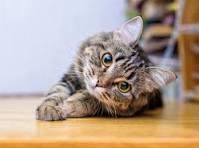

In [19]:
img = PILImage.create(upload.data[-1]) #rasm
pred, _, prob = learn.predict(img) #predict opportunity
print(f"Prediction: {pred}; Probability: {prob[1].item():.6f}")
img